In [1]:
import os
import pandas as pd

path = os.path.expanduser("~/VSCode/ML/Third_Eye/Datasets/malicious_urls.csv")
df = pd.read_csv(path)
df.head()

,url,type
0,br-icloud.com.br,phishing
1,mp3raid.com/music/krizz_kaliko.html,benign
2,bopsecrets.org/rexroth/cr/1.htm,benign
3,http://www.garage-pirenne.be/index.php?option=...,defacement
4,http://adventure-nicaragua.net/index.php?optio...,defacement


### Inspecting the Data

In [2]:
df.columns

Index(['url', 'type'], dtype='str')

> No missing values

In [3]:
df.isna().sum()

url     0
type    0
dtype: int64

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 651191 entries, 0 to 651190
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   url     651191 non-null  str  
 1   type    651191 non-null  str  
dtypes: str(2)
memory usage: 9.9 MB


### Types of calssifications for the URLs
* Begnin, Defacement, Phishing, Malware

In [5]:
df['type'].value_counts()

type
benign        428103
defacement     96457
phishing       94111
malware        32520
Name: count, dtype: int64

### Renaming columns for consistency

In [6]:
df = df[['url', 'type']]
df.columns = ['text', 'label']

In [7]:
df.head()

,text,label
0,br-icloud.com.br,phishing
1,mp3raid.com/music/krizz_kaliko.html,benign
2,bopsecrets.org/rexroth/cr/1.htm,benign
3,http://www.garage-pirenne.be/index.php?option=...,defacement
4,http://adventure-nicaragua.net/index.php?optio...,defacement


In [8]:
df = df.dropna()

In [9]:
df.tail()

,text,label
651186,xbox360.ign.com/objects/850/850402.html,phishing
651187,games.teamxbox.com/xbox-360/1860/Dead-Space/,phishing
651188,www.gamespot.com/xbox360/action/deadspace/,phishing
651189,en.wikipedia.org/wiki/Dead_Space_(video_game),phishing
651190,www.angelfire.com/goth/devilmaycrytonite/,phishing


### Cleaning URLs, processing it for tfidvectorization

* regular expression python module for textprocessing

In [10]:
import re

def clean_url(url):
    url = url.lower()           #lowercase all URLs
    url = re.sub(r"http[s]?://", "", url)       #[s]? meaning it is optional
    url = re.sub(r"www\.", "", url) 
    return url            #to delete www. in the URL

df['text'] = df['text'].apply(clean_url)
df.head()

,text,label
0,br-icloud.com.br,phishing
1,mp3raid.com/music/krizz_kaliko.html,benign
2,bopsecrets.org/rexroth/cr/1.htm,benign
3,garage-pirenne.be/index.php?option=com_content...,defacement
4,adventure-nicaragua.net/index.php?option=com_m...,defacement


### EDA

> Class Distribution

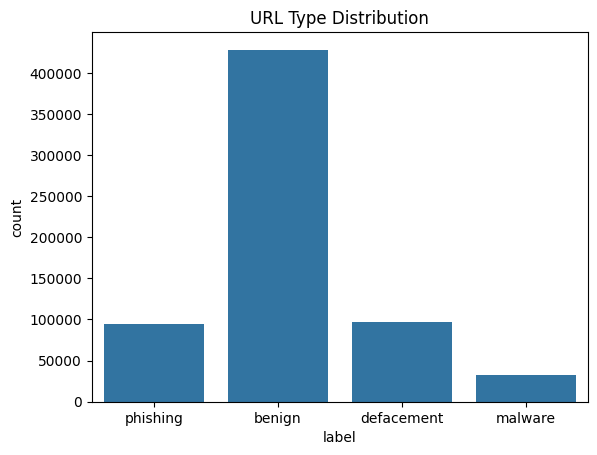

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=df['label'])
plt.title("URL Type Distribution")
plt.show()

> Begnin URLs outnumber the amount of malicious URLs which could prove to be a drawback of choosing this dataset

###  Distribution of URLs vs URL Character Length

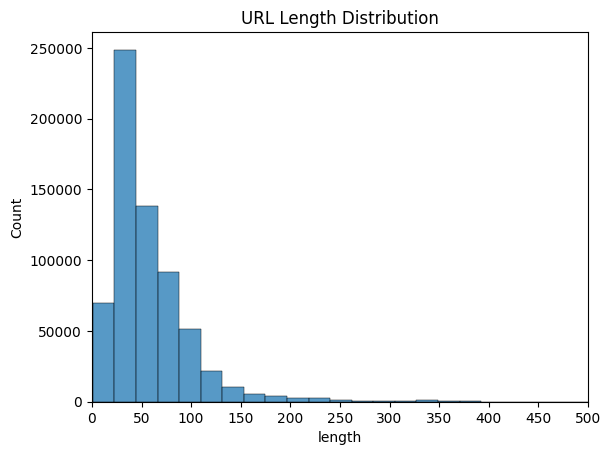

In [12]:
df['length'] = df['text'].apply(len)        #counts and stores no. of characters in each URL
                                            #into df[length]
sns.histplot(df['length'], bins=100)
plt.title("URL Length Distribution")
plt.xlim(0, 500)
plt.xticks(range(0, 501, 50))
plt.show()

### Train Test Split, 80% to train 20% to test

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df['text'], df['label'], test_size = 0.2, random_state=42
)

### Using Label Encoder to transform categorical text based label into numerical integers

In [14]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

### Feature Extraction using TF-IDF Vectorizer 
> Term Frequency - Inverse Document Frequency 
* Measures how frequently a word appears in document and how important it is (A product of TF and IDF scores)

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X_train_vec =vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

### Model 1 - Logistic Regression

In [16]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_vec, y_train)

y_pred_lr = lr.predict(X_test_vec)

### Model 2 - Naive Bayes

In [17]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train_vec, y_train)

y_pred_nb = nb.predict(X_test_vec)

### Results

In [18]:
from sklearn.metrics import classification_report

print("Logistic Regression:\n", classification_report(y_test, y_pred_lr))
print("Naive Bayes:\n", classification_report(y_test, y_pred_nb))

Logistic Regression:
               precision    recall  f1-score   support

           0       0.88      0.97      0.92     85778
           1       0.94      0.90      0.92     19104
           2       0.97      0.92      0.95      6521
           3       0.77      0.47      0.58     18836

    accuracy                           0.88    130239
   macro avg       0.89      0.81      0.84    130239
weighted avg       0.88      0.88      0.87    130239

Naive Bayes:
               precision    recall  f1-score   support

           0       0.86      0.95      0.90     85778
           1       0.91      0.85      0.88     19104
           2       0.93      0.85      0.89      6521
           3       0.70      0.43      0.53     18836

    accuracy                           0.86    130239
   macro avg       0.85      0.77      0.80    130239
weighted avg       0.85      0.86      0.85    130239



### Confusion Matrix
* compares the actual answer key test dataset with the guessed output from logistic regression 
> Exactly where the model is confused rather than just an accuracy percentage

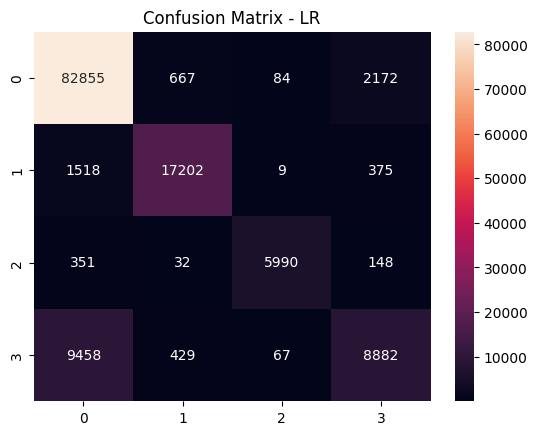

In [19]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - LR")
plt.show()

### Using Clustering

Custering is not ideal for this type of data consumes alot of time and gives out irregular results


In [20]:
import numpy as np

def test_new_url(new_url, trained_model, fitted_vectorizer, label_encoder):
    """
    Takes a raw URL, cleans it, and returns the multi-class prediction with confidence scores.
    """
    print(f"Testing URL: {new_url}")
    print("-" * 40)
    
    # 1. Clean the URL using the function you already defined in your notebook
    cleaned_url = clean_url(new_url)
    
    # 2. Vectorize the text using your fitted TF-IDF vectorizer
    vectorized_url = fitted_vectorizer.transform([cleaned_url])
    
    # 3. Get the numerical prediction (0, 1, 2, or 3) and the probability array
    prediction_num = trained_model.predict(vectorized_url)[0]
    probabilities = trained_model.predict_proba(vectorized_url)[0]
    
    # 4. Use your LabelEncoder to translate the number back into the text label
    prediction_text = label_encoder.inverse_transform([prediction_num])[0]
    
    # 5. Output the main classification result
    if prediction_text == 'benign':
        print(f"✅ Classification: {prediction_text.upper()}")
    else:
        print(f"🚨 Classification: {prediction_text.upper()}")
        
    print("\nConfidence Breakdown:")
    # 6. Loop through all 4 classes dynamically to show the exact percentage for each
    for i, class_name in enumerate(label_encoder.classes_):
        prob_percentage = probabilities[i] * 100
        print(f" - {class_name.capitalize()}: {prob_percentage:.2f}%")
    print("\n" + "="*40 + "\n")

# --- Let's test it using some examples! ---

# A likely benign URL
test_new_url("https://www.google.com/search?q=puppies", lr, vectorizer, le)

# A phishing URL (taken directly from the head of your dataset)
test_new_url("br-icloud.com.br", lr, vectorizer, le)

# A defacement URL (taken directly from the head of your dataset)
test_new_url("http://adventure-nicaragua.net/index.php?option=com_m...", lr, vectorizer, le)

Testing URL: https://www.google.com/search?q=puppies
----------------------------------------
✅ Classification: BENIGN

Confidence Breakdown:
 - Benign: 79.20%
 - Defacement: 0.18%
 - Malware: 0.96%
 - Phishing: 19.66%


Testing URL: br-icloud.com.br
----------------------------------------
🚨 Classification: PHISHING

Confidence Breakdown:
 - Benign: 2.53%
 - Defacement: 5.72%
 - Malware: 0.40%
 - Phishing: 91.35%


Testing URL: http://adventure-nicaragua.net/index.php?option=com_m...
----------------------------------------
🚨 Classification: DEFACEMENT

Confidence Breakdown:
 - Benign: 0.66%
 - Defacement: 97.63%
 - Malware: 0.42%
 - Phishing: 1.29%




### Exporting pickle files

In [ ]:
import os
import joblib

SAVE_DIR = "/Users/avomine/VSCode/ML/Third_Eye/toPickleFiles/url_models"
os.makedirs(SAVE_DIR, exist_ok=True)

# ------------------------
# SAFETY CHECK
# ------------------------
required_vars = ["lr", "nb", "vectorizer", "le"]

for var in required_vars:
    if var not in globals():
        raise ValueError(f"{var} is not defined. Run training cells first.")

# ------------------------
# Save individual files
# ------------------------

joblib.dump(lr, os.path.join(SAVE_DIR, "url_lr_model.pkl"))
joblib.dump(nb, os.path.join(SAVE_DIR, "url_nb_model.pkl"))

joblib.dump(vectorizer, os.path.join(SAVE_DIR, "url_vectorizer.pkl"))
joblib.dump(le, os.path.join(SAVE_DIR, "url_label_encoder.pkl"))

# save cleaner
joblib.dump(clean_url, os.path.join(SAVE_DIR, "url_cleaner.pkl"))

# ------------------------
# Save bundle (BEST)
# ------------------------

bundle = {
    "lr": lr,
    "nb": nb,
    "vectorizer": vectorizer,
    "label_encoder": le,
    "clean_url": clean_url
}

joblib.dump(bundle, os.path.join(SAVE_DIR, "url_model_bundle.pkl"))

print("✅ URL model exported successfully")

✅ URL model exported successfully
